In [1]:
import torch
import torch.nn as nn

from torch import Tensor
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from torchvision.models import alexnet
from torchsummary import summary
from tinyimagenet import TinyImageNet

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from utils.activation_maps import ActivationMaps

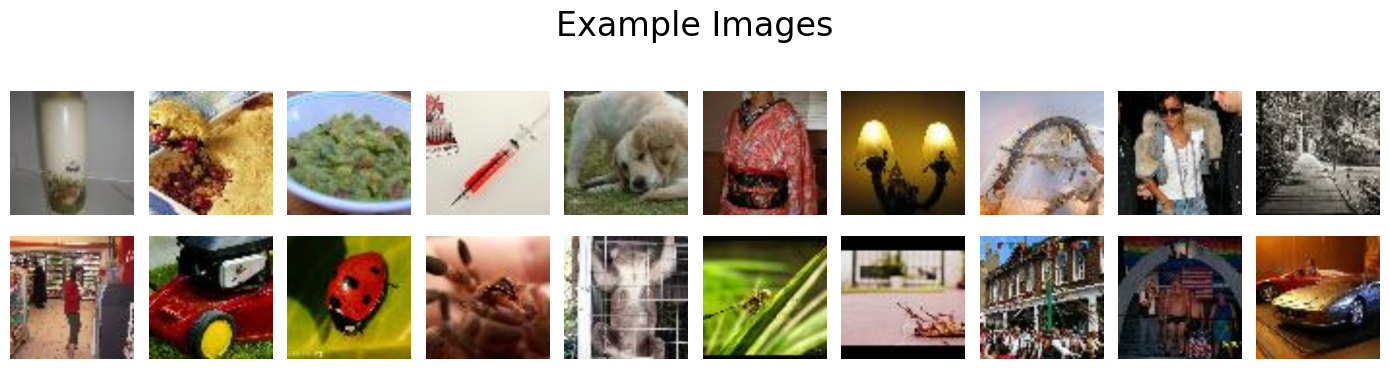

In [2]:
## Import dataset
transform = T.Compose([
    T.Resize((226, 226)),
    T.ToTensor()
])

imagenet_PATH = Path("DeepCluster/data/imagenet")
imagenet = TinyImageNet(imagenet_PATH, split="test", transform=transform)
# print(imagenet)

## Plot examples
plt.figure(figsize=(14, 4))
plt.suptitle("Example Images", fontsize=24)
for i, idx in enumerate(np.random.randint(low=0, high=10000, size=20)):
    img, _ = imagenet[i]
    plt.subplot(2, 10, i+1)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
alexnet = alexnet(weights="DEFAULT")
model = alexnet.features

summary(model=model, input_size=imagenet[0][0].shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 55, 55]          23,296
              ReLU-2           [-1, 64, 55, 55]               0
         MaxPool2d-3           [-1, 64, 27, 27]               0
            Conv2d-4          [-1, 192, 27, 27]         307,392
              ReLU-5          [-1, 192, 27, 27]               0
         MaxPool2d-6          [-1, 192, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         663,936
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 256, 13, 13]         884,992
             ReLU-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         590,080
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
Total params: 2,469,696
Trainable param

In [4]:
img, label = imagenet[1200]
maps = ActivationMaps(model=model)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

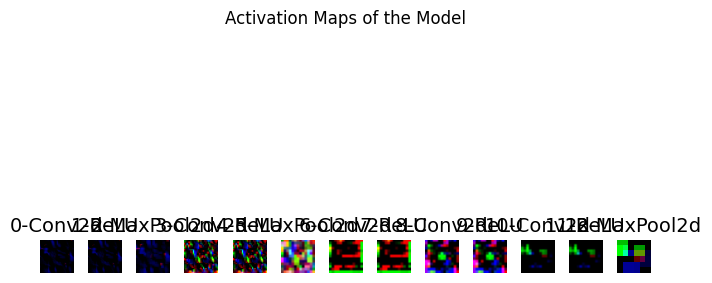

{'0-Conv2d': tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]],
 
         [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,

In [5]:
maps(img, visuals=True)

## TODO:

#### Get top 10 most activating input images and plot

**`Probing deeper layers :`** We assess the quality of a target filter by learning an input image that maximizes its activation . We follow the process described by Yosinki et al. with a cross entropy function between the target filter and the other filters of the same layer. Figure 4 shows these synthetic images as well as the 9 top activated images from a subset of 1 million images from YFCC100M. As expected, deeper layers in the network seem to capture larger textural structures. However, some filters in the last convolutional layers seem to be simply replicating the texture already captured in previous layers...